# Phase 5.3: Analisis Akurasi Per-Subjek

**Tujuan:** LOSO (5.2) menghasilkan 1 skor akurasi per subjek yang di-hold-out (15 subjek).
Notebook ini memecah `Mean_Accuracy` menjadi granularitas per-subjek untuk menjawab: **subjek mana
yang sinyal EEG-nya mudah digeneralisasi ke model yang dilatih dari 14 subjek lain, dan subjek mana
yang sulit (kemungkinan karena variabilitas individu tinggi / sinyal noisy)?**

Ini penting untuk skripsi karena keterbatasan subject-independent EEG classification (variabilitas
antar-individu) adalah temuan yang relevan untuk dibahas di Bab 3.4 (keterbatasan), terlepas dari
akurasi rata-rata keseluruhan.

In [1]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.facecolor'] = 'white'

PHASE3_CSV_DIR = r"D:\Skripsi\new_data\phase_3_feature_engineering\csv"
ROI_DIR = r"D:\Skripsi\new_data\phase_3_feature_engineering\3.4_roi_aggregation\output"
TUNING_PARAMS_CSV = r"D:\Skripsi\new_data\phase_4_classification\4.6_hyperparameter_tuning\output\tuning_best_params.csv"
BASE = r"D:\Skripsi\new_data\phase_5_loso"
KEY_COLS = ['subject_id', 'subject_num', 'session', 'trial', 'class', 'class_label']

def _feature_cols(df):
    exclude = KEY_COLS + [c for c in df.columns if 'hub_channel' in c]
    cols = [c for c in df.columns if c not in exclude and df[c].dtype in ['float64', 'int64']]
    return [c for c in cols if df[c].std() > 1e-10]

print("Setup OK.")

Setup OK.


In [2]:
DIR_52 = os.path.join(BASE, "5.2_loso_all_models", "output")
DIR_53_FIG = os.path.join(BASE, "5.3_loso_analysis", "figures")
DIR_53_OUT = os.path.join(BASE, "5.3_loso_analysis", "output")
os.makedirs(DIR_53_FIG, exist_ok=True)
os.makedirs(DIR_53_OUT, exist_ok=True)

df_subj = pd.read_csv(os.path.join(DIR_52, 'loso_per_subject.csv'))
dataset_order = ['GC', [c for c in df_subj['Dataset'].unique() if c.startswith('PDC_')][0],
                  'Spectral', 'Combined', 'GC+PDC_ROI+Spectral']
print(f"Loaded {len(df_subj)} per-subject rows, {df_subj['Dataset'].nunique()} datasets, "
      f"{df_subj['Held_Subject'].nunique()} subjects.")

Loaded 375 per-subject rows, 5 datasets, 15 subjects.


## Bar Chart Akurasi per Subjek (Model Terbaik per Dataset)

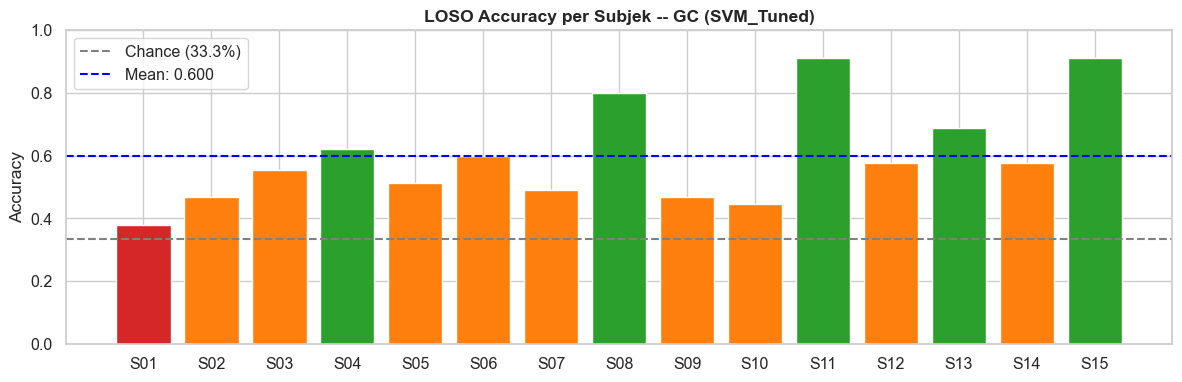

GC: best model=SVM_Tuned, range=[0.378, 0.911], mean=0.600


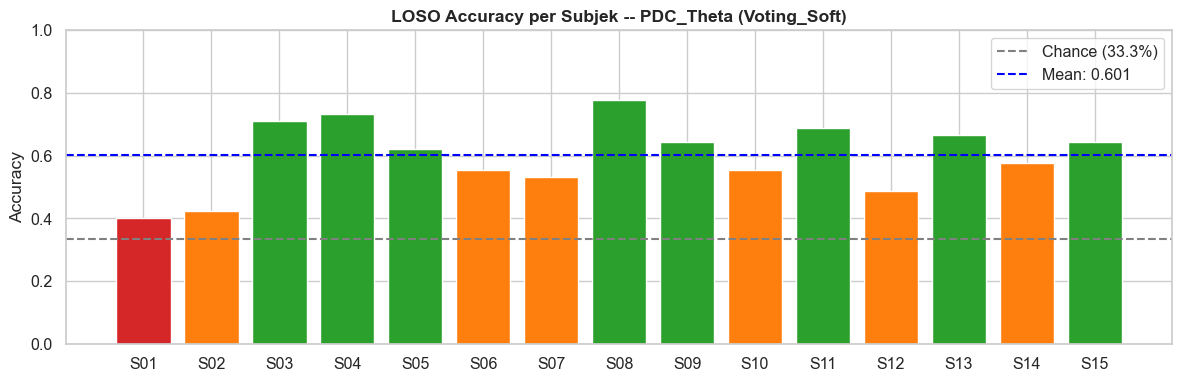

PDC_Theta: best model=Voting_Soft, range=[0.400, 0.778], mean=0.601


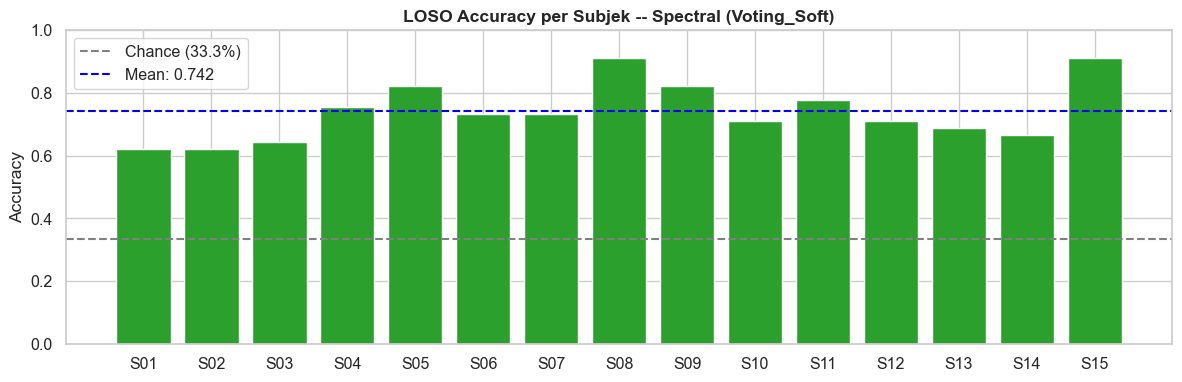

Spectral: best model=Voting_Soft, range=[0.622, 0.911], mean=0.742


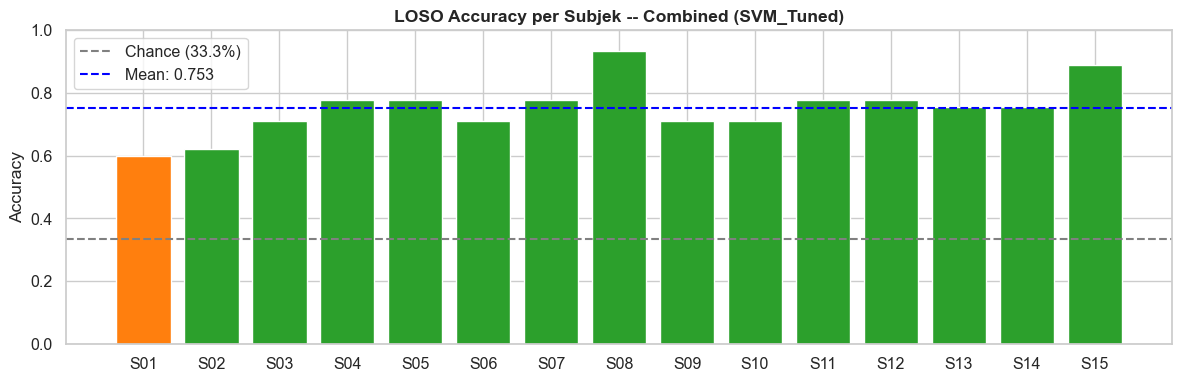

Combined: best model=SVM_Tuned, range=[0.600, 0.933], mean=0.753


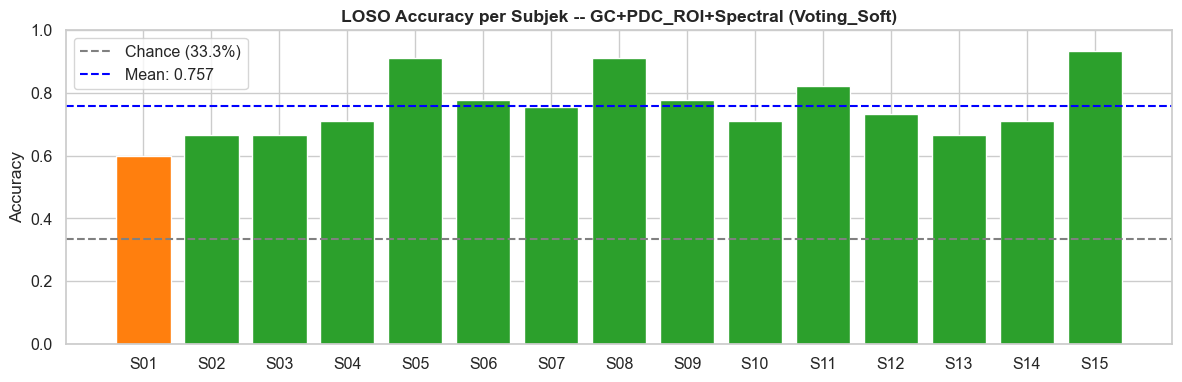

GC+PDC_ROI+Spectral: best model=Voting_Soft, range=[0.600, 0.933], mean=0.757


In [3]:
best_per_subject_rows = []
for name in dataset_order:
    sub = df_subj[df_subj['Dataset'] == name]
    best_model = sub.groupby('Model')['Accuracy'].mean().idxmax()
    row = sub[sub['Model'] == best_model].sort_values('Held_Subject')

    fig, ax = plt.subplots(figsize=(12, 4))
    accs = row['Accuracy'].values
    subjects = [f"S{s:02d}" for s in row['Held_Subject'].values]
    colors = ['#2ca02c' if a > 0.6 else '#ff7f0e' if a > 0.4 else '#d62728' for a in accs]
    ax.bar(subjects, accs, color=colors)
    ax.axhline(y=1/3, color='gray', linestyle='--', label='Chance (33.3%)')
    ax.axhline(y=accs.mean(), color='blue', linestyle='--', label=f"Mean: {accs.mean():.3f}")
    ax.set_title(f"LOSO Accuracy per Subjek -- {name} ({best_model})", fontweight='bold')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)
    ax.legend()
    plt.tight_layout()
    safe = name.lower().replace('+', '_').replace(' ', '_')
    fig.savefig(os.path.join(DIR_53_FIG, f"5.3_per_subject_{safe}.png"), dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"{name}: best model={best_model}, range=[{accs.min():.3f}, {accs.max():.3f}], mean={accs.mean():.3f}")
    for s, a in zip(row['Held_Subject'].values, accs):
        best_per_subject_rows.append({'Dataset': name, 'Model': best_model, 'Subject': s, 'Accuracy': a})

## Subjek Paling Konsisten Sulit/Mudah (rata-rata lintas 5 dataset)

In [ ]:
df_bps = pd.DataFrame(best_per_subject_rows)
df_bps.to_csv(os.path.join(DIR_53_OUT, 'best_model_per_subject.csv'), index=False)

subj_avg = df_bps.groupby('Subject')['Accuracy'].agg(['mean', 'std']).sort_values('mean')
subj_avg.columns = ['Mean_Accuracy_Across_Datasets', 'Std_Accuracy_Across_Datasets']
subj_avg.to_csv(os.path.join(DIR_53_OUT, 'subject_difficulty_ranking.csv'))
print("5 subjek PALING SULIT digeneralisasi (rata-rata akurasi terendah lintas 5 dataset):")
print(subj_avg.head(5).to_string())
print()
print("5 subjek PALING MUDAH digeneralisasi:")
print(subj_avg.tail(5).sort_values('Mean_Accuracy_Across_Datasets', ascending=False).to_string())

5 subjek PALING SULIT digeneralisasi (rata-rata akurasi terendah lintas 5 dataset):
         Mean_Accuracy_Across_Datasets  Std_Accuracy_Across_Datasets
Subject                                                             
1                             0.520000                      0.120288
2                             0.560000                      0.108184
10                            0.626667                      0.122121
3                             0.657778                      0.064022
12                            0.657778                      0.120288

5 subjek PALING MUDAH digeneralisasi:
         Mean_Accuracy_Across_Datasets  Std_Accuracy_Across_Datasets
Subject                                                             
8                             0.866667                      0.072008
15                            0.857778                      0.120288
11                            0.795556                      0.080737
5                             0.728889           

**Kesimpulan 5.3:** Analisis per-subjek menunjukkan sebaran akurasi yang cukup lebar antar
individu (lihat rentang di setiap bar chart) -- ini mengonfirmasi variabilitas antar-subjek yang
memang menjadi tantangan klasik EEG-based emotion recognition (subject-independent). Subjek dengan
akurasi konsisten rendah lintas semua tipe fitur (bukan cuma 1 dataset) kemungkinan punya sinyal EEG
yang secara intrinsik lebih noisy / pola emosinya lebih idiosinkratik -- poin relevan untuk
keterbatasan penelitian di Bab 3.4.